In [1669]:
# -----------------------------
# 1. Imports
# -----------------------------

import os
import random
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

os.environ["OMP_NUM_THREADS"] = "20"

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set(style="whitegrid", palette="muted", font_scale=1.2)



In [1670]:

# -----------------------------
# 2. PARSER
# Parse ACH text files by extracting valid 94‑character entry detail records
# and pulling key NACHA fields (routing, account, transaction code, amount, debit/credit flag) into a clean DataFrame for analysis.
# -----------------------------

records = []

for f in glob.glob("data/*.txt"):
    with open(f, "r") as fh:
        for line in fh:
            line = line.rstrip("\r\n")

            # skip malformed lines
            if len(line) < 94:
                continue

            # force to exactly 94 chars
            line = line[:94]

            # only entry detail records
            if not line.startswith("6"):
                continue

            transaction_code = line[1:3]
            dfi = line[3:12]
            routing = dfi[:8]
            account = line[12:29].strip()
            sec = line[50:52]

            amount_str = line[29:39].strip()
            if not amount_str.isdigit():
                continue
            amount = int(amount_str)

            debit_credit_flag = (
                "C" if transaction_code in ["20", "21", "22", "23", "24", "28"]
                else "D"
            )

            records.append({
                "routing": routing,
                "account": account,
                "transaction_code" : transaction_code,
                "amount": amount,
                "debit_credit_flag": debit_credit_flag
            })

df = pd.DataFrame(records)
print(df.head())
print(df.shape)


    routing            account transaction_code  amount debit_credit_flag
0  06100010  89349878025138574               30    4008                 D
1  03110050  13788833110310434               28    4318                 C
2  11100061  99110144070308859               20    5847                 C
3  11100061  39594704095936084               27    1033                 D
4  12100035  31072584833696406               24   31603                 C
(5020, 5)


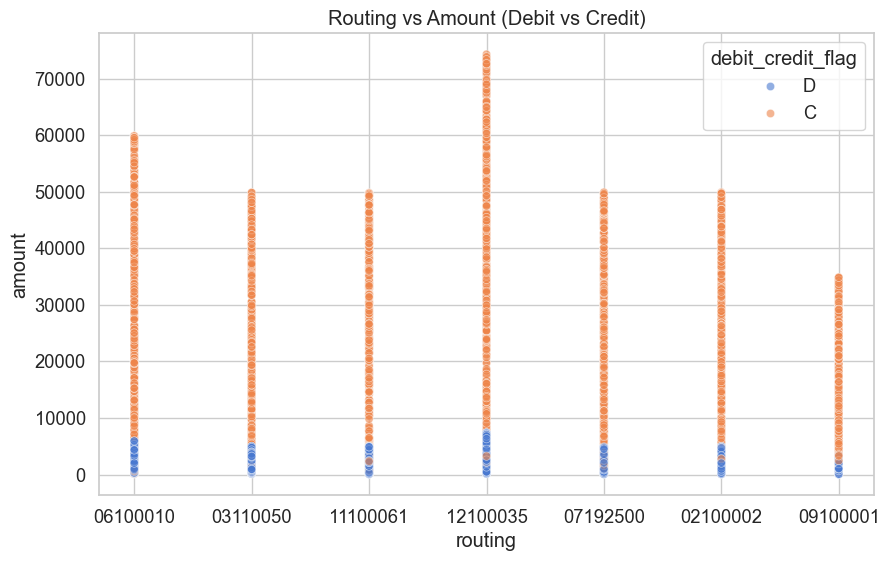

In [1671]:
# -----------------------------
# 3. FEATURE CLEANUP
# -----------------------------

df["amount_scaled"] = StandardScaler().fit_transform(df[["amount"]])
df["routing_region"] = df["routing"].str[:2].astype(int)
df["is_credit"] = (df["debit_credit_flag"] == "C").astype(int)

#Idenfity the columns we will be using for this project.
X = df[["amount_scaled","routing_region", "is_credit"]]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="routing",
    y="amount",
    hue="debit_credit_flag",
    alpha=0.6,
    data=df
)
plt.title("Routing vs Amount (Debit vs Credit)")
plt.show()



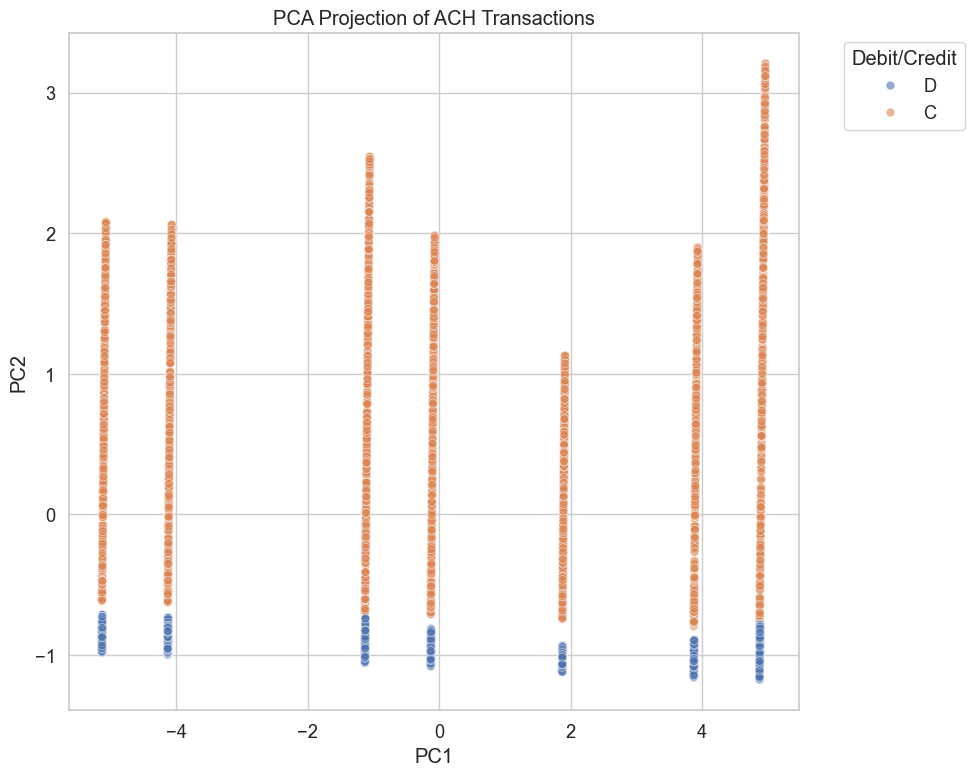

In [1672]:

# -----------------------------
# 4. PCA
# Apply PCA to reduce the feature space to two components and visualize how
# debit and credit transactions separate in PCA space.
# -----------------------------

pca = PCA(n_components=3)
pcs = pca.fit_transform(X)

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]


plt.figure(figsize=(10, 8))
sns.scatterplot(data = df,
    x="PC1",
    y="PC2",
    hue="debit_credit_flag",
    palette=["#4C72B0", "#DD8452"],  # clean blue/orange
    alpha=0.6,
    s=40
)

plt.title("PCA Projection of ACH Transactions")
plt.legend(title="Debit/Credit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()




C:\Users\ramya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


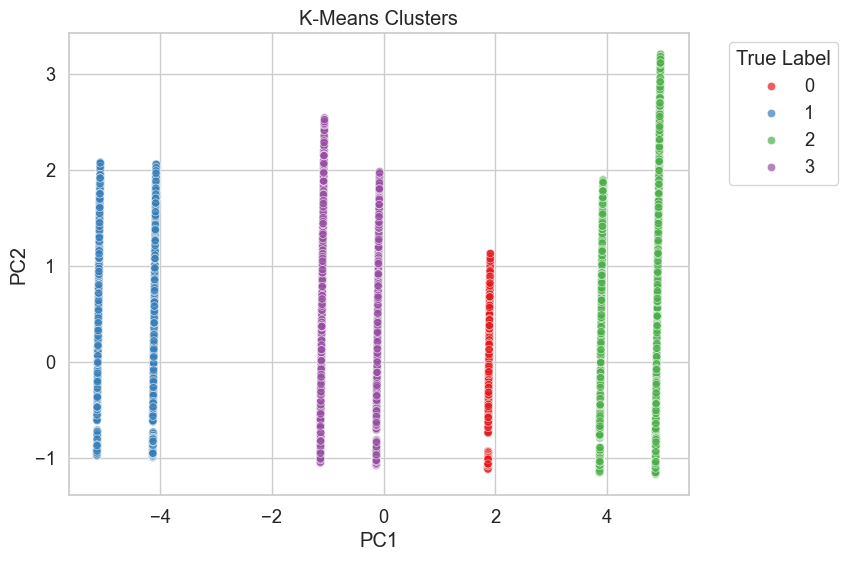

In [1673]:
# -----------------------------
# 5. K-MEANS
#This code assigns each record to one of four K‑Means clusters and projects them onto PC1 and PC2. 
#The scatterplot highlights how well the clusters spread out in PCA space.
# -----------------------------

kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df["Cluster"] = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=df, palette="Set1", alpha=0.7)
plt.title("K-Means Clusters")
plt.legend(title="True Label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       213
           1       1.00      1.00      1.00       433
           2       1.00      1.00      1.00       420
           3       1.00      1.00      1.00       440

    accuracy                           1.00      1506
   macro avg       1.00      1.00      1.00      1506
weighted avg       1.00      1.00      1.00      1506



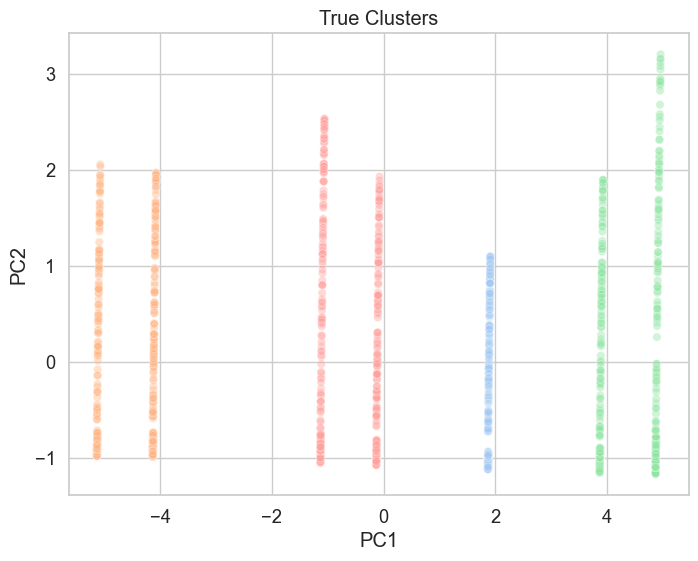

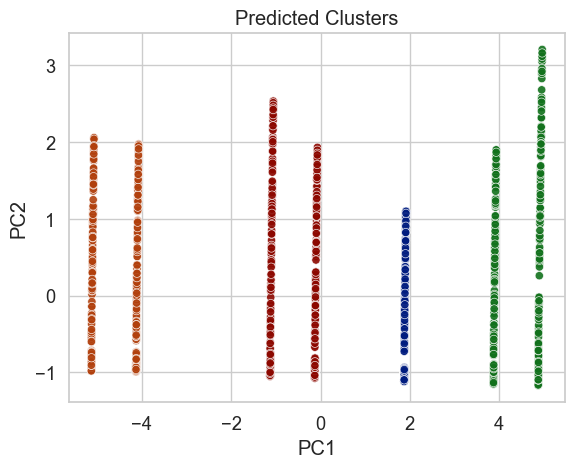

In [1674]:
# -----------------------------
# 6. LOGISTIC REGRESSION
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df[["PC1", "PC2"]],
    df["Cluster"],
    test_size=0.3,
    random_state=42,
    stratify=df["Cluster"]
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_test["PC1"],
    y=X_test["PC2"],
    hue=y_test,
    palette="pastel",
    alpha=0.4,
    legend=False
)
plt.title("True Clusters")
plt.show()


#Predictions
sns.scatterplot(
    x=X_test["PC1"],
    y=X_test["PC2"],
    hue=y_pred,
    palette="dark",
    alpha=0.9,
    legend=False
)
plt.title("Predicted Clusters")
plt.show()





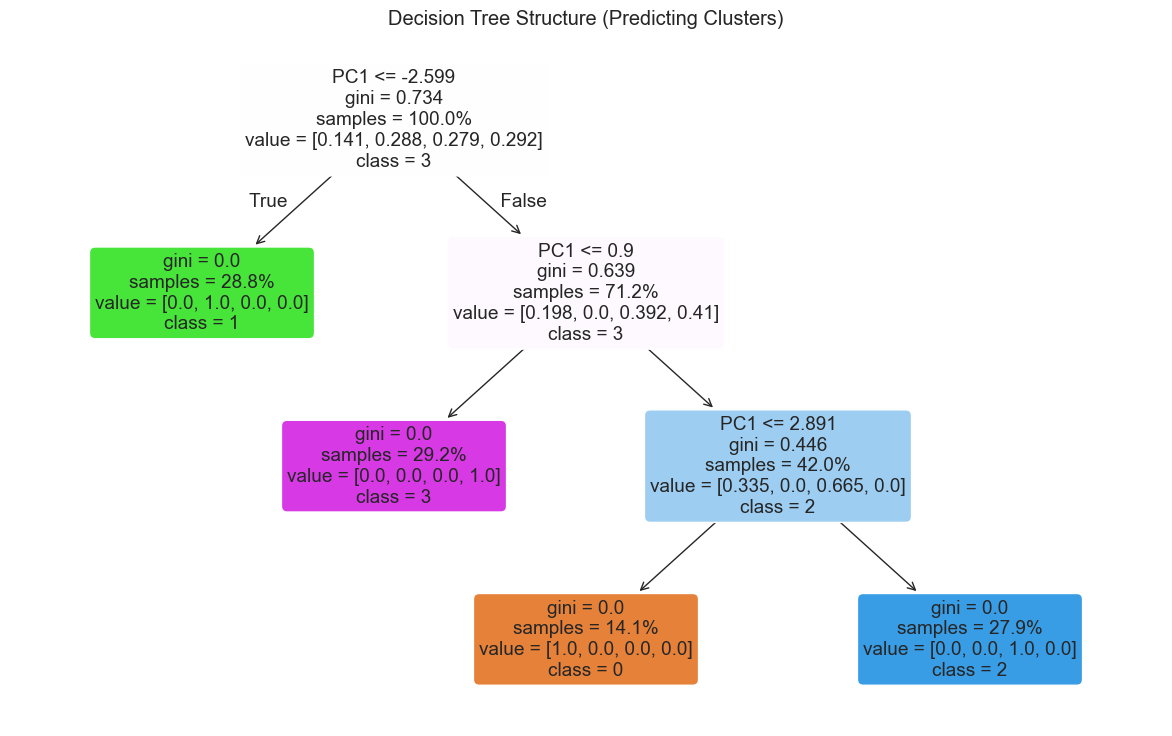

In [1675]:
# -----------------------------
# 7. DECISION TREE CLASSIFIER
# -----------------------------

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

# Features and target
X = df[["PC1", "PC2"]]
y = df["Cluster"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Fit model
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

# Plot tree

depth = dt.get_depth()
leaves = dt.get_n_leaves()

width = max(12, leaves * 1.2)
height = max(6, depth * 3)

plt.figure(figsize=(width, height))


plot_tree(
    dt,
    feature_names=["PC1", "PC2"],
    class_names=[str(c) for c in sorted(df["Cluster"].unique())],
    filled=True,
    rounded=True,
    proportion=True
)
plt.title("Decision Tree Structure (Predicting Clusters)")
plt.subplots_adjust(left=0.02, right=0.98)

plt.show()


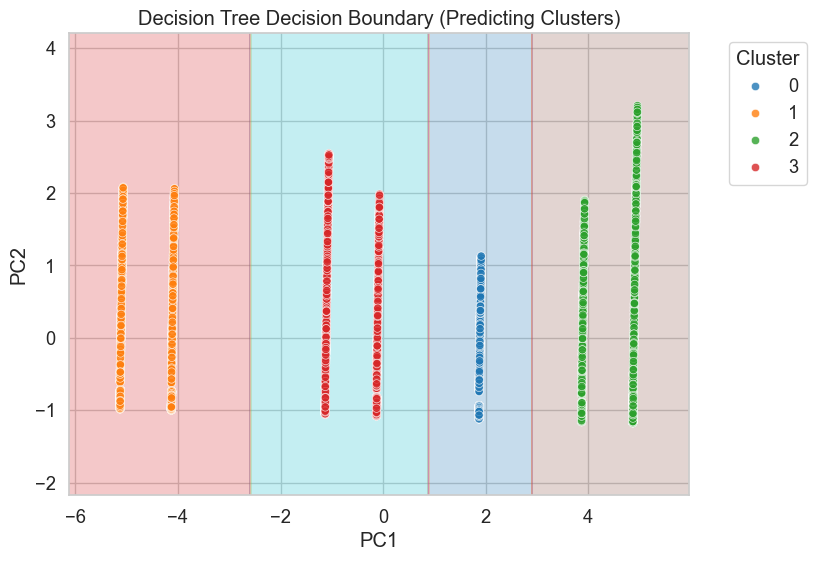

In [1676]:
# Create mesh grid
x_min, x_max = df["PC1"].min() - 1, df["PC1"].max() + 1
y_min, y_max = df["PC2"].min() - 1, df["PC2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict on grid
grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=["PC1", "PC2"]
)

Z = dt.predict(grid)

# Convert cluster labels to integers for contourf
Z_numeric = Z.astype(int).reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(xx, yy, Z_numeric, alpha=0.25, cmap="tab10")

# Actual points (true clusters)
sns.scatterplot(
    x=df["PC1"],
    y=df["PC2"],
    hue=df["Cluster"],
    palette="tab10",
    alpha=0.8
)

plt.title("Decision Tree Decision Boundary (Predicting Clusters)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [1677]:
#---------------------------------------------------------------------------------------
# Function to write an ACH file with dummy header info from the consolidated sampling
# Input is the sampled dataframe
#------------------------------------------------------------------------------------------

def write_consolidated_ach_file_from_sample(sampled_df, output_path="data/consolidated_ach_file.txt"):
    import os, datetime
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    now = datetime.datetime.now()
    yymmdd = now.strftime("%y%m%d")
    hhmm = now.strftime("%H%M")

    file_header = (
        "1"
        + "123456789".rjust(10)
        + "987654321".rjust(10)
        + yymmdd
        + hhmm
        + "A"
        + "094"
        + "10"
        + "1"
        + "CONSOLIDATED ACH FILE".ljust(23)
    ).ljust(94)

    batch_header = (
        "5"
        + "200"
        + "MY COMPANY".ljust(16)
        + "123456789"
        + "CON"
        + "CONSOL".ljust(10)
        + yymmdd
        + "".ljust(6)
        + "1"
        + "98765432"
        + "0000001"
    ).ljust(94)

    entries = []
    total_amount = 0
    entry_count = 0

    for _, row in sampled_df.iterrows():
        entry_count += 1
        amount = int(row["amount"])
        total_amount += amount
        trace = "98765432" + str(entry_count).zfill(7)

        entry = (
            "6"
            + str(row["transaction_code"]).zfill(2)
            + row["routing"][:8]
            + " "                                # pos 11
            + row["account"].ljust(17)           # pos 12–28
            + str(amount).zfill(10)              # pos 29–38
            + "".ljust(15)                       # pos 39–53
            + row.get("name", "CONSUMER").ljust(22)  # pos 54–75
            + trace                              # pos 76–93
        ).ljust(94)

        entries.append(entry)

    batch_control = (
        "8"
        + "000001"
        + str(entry_count).zfill(6)
        + str(total_amount).zfill(12)
        + "".ljust(12)
        + "98765432"
        + "0000001"
    ).ljust(94)

    record_count = 1 + 1 + entry_count + 1 + 1
    block_count = (record_count + 9) // 10

    file_control = (
        "9"
        + "000001"
        + str(block_count).zfill(6)
        + str(entry_count).zfill(8)
        + str(total_amount).zfill(12)
        + "".ljust(39)
    ).ljust(94)

    with open(output_path, "w") as f:
        f.write(file_header + "\n")
        f.write(batch_header + "\n")
        for e in entries:
            f.write(e + "\n")
        f.write(batch_control + "\n")
        f.write(file_control + "\n")


In [1678]:
# Sample by cluster
# From the observations above, I preferred clustered as it provided best visualization.

sampled_df = df.groupby("Cluster").sample(5) # 5 samples per cluster (a total of 20 records
write_consolidated_ach_file_from_sample(sampled_df)



=== Evaluating Consolidated ACH File ===



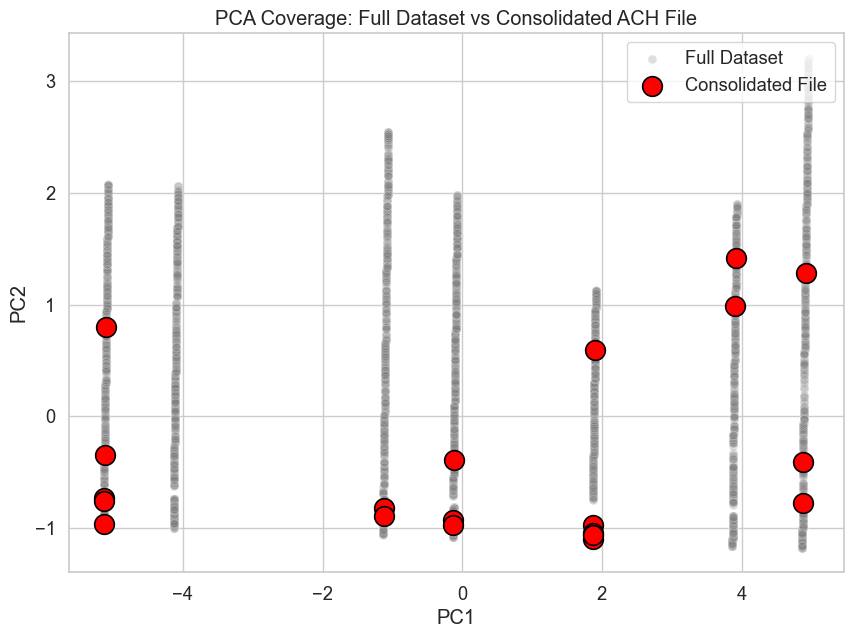

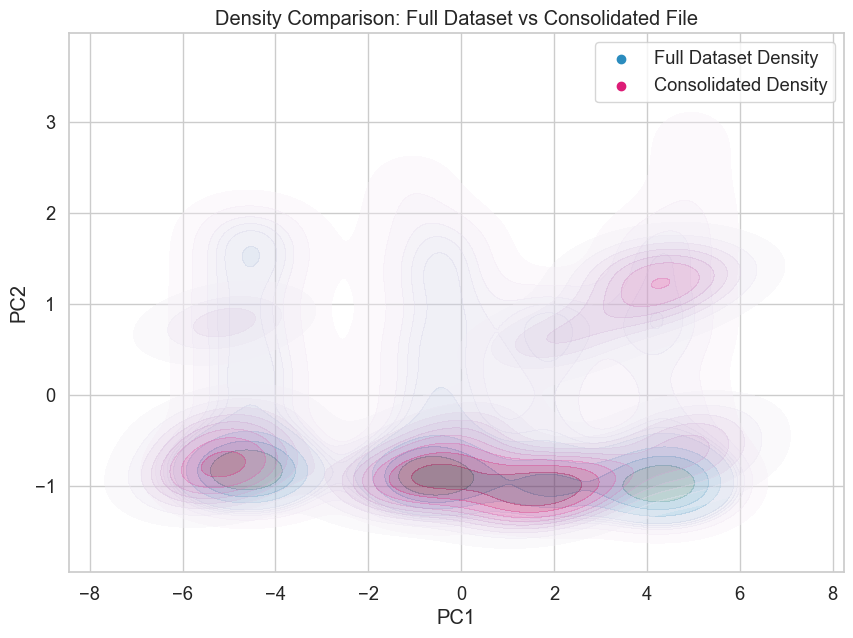

<Figure size 1000x700 with 0 Axes>

In [1679]:
# ============================================================
# EVALUATION + PCA OVERLAY PLOT
# This section has two parts, to read the newly generated consolidated ACH file and compare it against the original dataframe
# ============================================================

from scipy.stats import ks_2samp
from sklearn.neighbors import NearestNeighbors

def parse_consolidated_file(path):
    """Parse the consolidated ACH file into a DataFrame."""
    rows = []
    with open(path, "r") as fh:
        for line in fh:
            line = line.rstrip("\n")
            if len(line) < 94 or not line.startswith("6"):
                continue
            transaction_code = line[1:3]
            routing = line[3:11][:8]
            amount = int(line[29:39])
            dc = "C" if line[1:3] in ["20","21","22","23","24","28"] else "D"

            rows.append({
                "routing": routing,
                "amount": amount,
                "debit_credit_flag": dc,
                "transaction_code" : transaction_code
            })

    return pd.DataFrame(rows)


def evaluate_consolidation(df, consolidated_path="data/consolidated_ach_file.txt"):
    print("\n=== Evaluating Consolidated ACH File ===\n")

    # -----------------------------
    # Load consolidated file
    # -----------------------------
    con_df = parse_consolidated_file(consolidated_path)

    # Feature engineering to match full dataset
    con_df["routing_region"] = con_df["routing"].str[:2].astype(int)
    con_df["is_credit"] = (con_df["debit_credit_flag"] == "C").astype(int)

    # Scale amount using the SAME scaler as full dataset
    scaler = StandardScaler().fit(df[["amount"]])
    con_df["amount_scaled"] = scaler.transform(con_df[["amount"]])

    # PCA transform using the SAME PCA model
    con_pcs = pca.transform(con_df[["amount_scaled", "routing_region", "is_credit"]])
    con_df["PC1"] = con_pcs[:, 0]
    con_df["PC2"] = con_pcs[:, 1]

    # Assign clusters using the SAME KMeans model
    con_df["Cluster"] = kmeans.predict(con_df[["amount_scaled", "routing_region", "is_credit"]])

      # ============================================================
    # 1. PCA OVERLAY PLOT
    # ============================================================

    plt.figure(figsize=(10, 7))

    # Full dataset cloud
    sns.scatterplot(
        x=df["PC1"], y=df["PC2"],
        alpha=0.25, s=40, color="gray",
        label="Full Dataset"
    )

    # Consolidated file points
    sns.scatterplot(
        x=con_df["PC1"], y=con_df["PC2"],
        s=200, color="red",
        edgecolor="black", linewidth=1.2,
        label="Consolidated File"
    )

    plt.title("PCA Coverage: Full Dataset vs Consolidated ACH File")
    plt.legend(loc="upper right")
    plt.show()

    # ============================================================
    # 2. DENSITY COMPARISON PLOT
    # ============================================================

    plt.figure(figsize=(10, 7))

    sns.kdeplot(
        x=df["PC1"], y=df["PC2"],
        fill=True, cmap="PuBuGn",
        alpha=0.35, thresh=0.05
    )

    sns.kdeplot(
        x=con_df["PC1"], y=con_df["PC2"],
        fill=True, cmap="PuRd",
        alpha=0.35, thresh=0.05,
        bw_adjust=0.5
    )

    plt.scatter([], [], color="#2b8cbe", label="Full Dataset Density")   # teal
    plt.scatter([], [], color="#dd1c77", label="Consolidated Density")   # magenta

    plt.title("Density Comparison: Full Dataset vs Consolidated File")
    plt.legend(loc="upper right")
    plt.show()

    plt.figure(figsize=(10, 7))

# Run evaluation
con_df = evaluate_consolidation(df)
    

In [1680]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load consolidated dataset
# ---------------------------------------------------------

cons_df = parse_consolidated_file("data/consolidated_ach_file.txt")


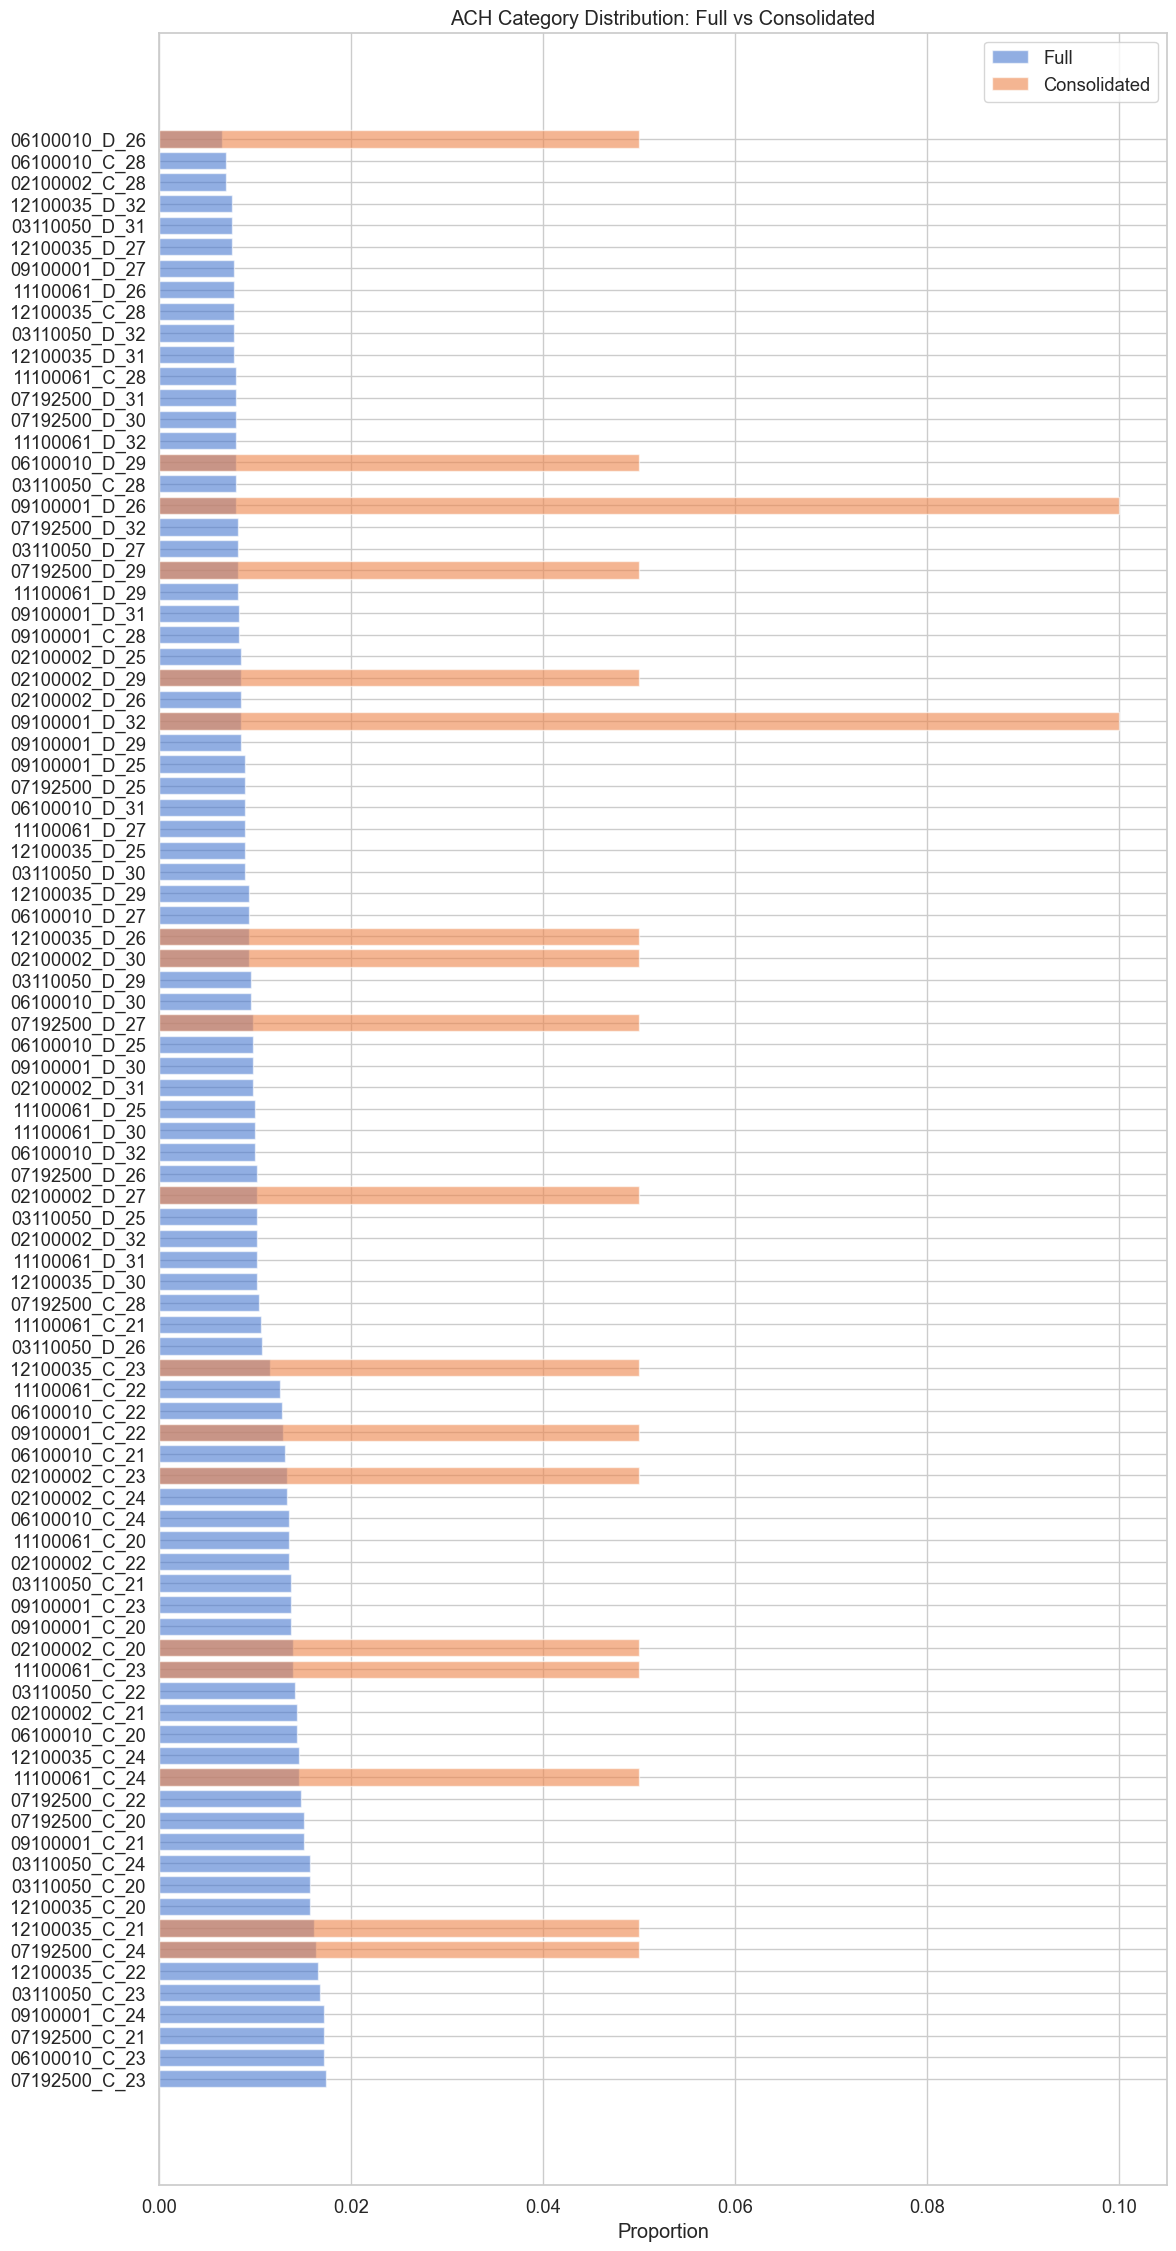

In [1681]:
#Side-by side plot to demonstrate the distribution of the records in the consolidated file vs individual ACH files.

def plot_side_by_side(full_df, cons_df):

    def make_key(df):
        return (
            df["routing"].astype(str) + "_" +
            df["debit_credit_flag"].astype(str) + "_" +
            df["transaction_code"].astype(str)
        )

    full_prop = make_key(full_df).value_counts(normalize=True)
    cons_prop = make_key(cons_df).value_counts(normalize=True)

    coverage = pd.DataFrame({
        "full": full_prop,
        "cons": cons_prop
    }).fillna(0)

    coverage = coverage.sort_values("full", ascending=False)

    plt.figure(figsize=(12, max(6, len(coverage) * 0.25)))

    plt.barh(coverage.index, coverage["full"], alpha=0.6, label="Full")
    plt.barh(coverage.index, coverage["cons"], alpha=0.6, label="Consolidated")

    plt.xlabel("Proportion")
    plt.title("ACH Category Distribution: Full vs Consolidated")
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_side_by_side(df, cons_df)